<a href="https://colab.research.google.com/github/Martin1421cl/mineria_datos/blob/main/Evaluaci%C3%B3n_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sys
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [ ]:
df = pd.read_csv("/content/Smartphone_Usage_And_Addiction_Analysis_7500_Rows .csv")

## Contexto del Dataset: Análisis de Uso y Adicción al Smartphone

Este dataset contiene información detallada sobre el uso de smartphones y factores relacionados con la adicción en una muestra de usuarios. Los datos incluyen variables como el tiempo diario de pantalla, horas dedicadas a redes sociales, juegos, trabajo/estudio, horas de sueño, notificaciones recibidas, aperturas de aplicaciones, y tiempo de pantalla durante el fin de semana. También se recopilan datos demográficos como edad y género, así como niveles percibidos de estrés y si el uso del smartphone impacta el trabajo académico.

La columna objetivo principal es `addicted_label`, una variable binaria que indica si un usuario es considerado adicto al smartphone (1) o no (0). Adicionalmente, `addiction_level` proporciona un nivel de adicción más granular (leve, moderado, severo), aunque con algunos valores faltantes que serán tratados durante el preprocesamiento.

El objetivo de este análisis es construir modelos predictivos para identificar a usuarios con riesgo de adicción al smartphone, así como comprender los factores clave que contribuyen a este fenómeno.

In [ ]:
df.head(50)

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1
5,TXN00006,U00006,26,Male,9.32,4.26,0.29,3.99,6.90,82,56,10.98,Medium,Yes,Severe,1
6,TXN00007,U00007,25,Male,10.40,4.93,1.60,0.86,8.61,165,95,11.43,Medium,No,Severe,1
7,TXN00008,U00008,26,Male,4.26,4.60,2.16,4.61,6.43,169,117,5.66,Low,No,Moderate,1
8,TXN00009,U00009,21,Other,4.38,1.38,2.72,3.78,6.23,172,134,6.20,High,Yes,NaN,0
9,TXN00010,U00010,35,Other,9.76,4.73,1.36,2.11,5.21,20,82,12.69,Low,Yes,Severe,1


###Justificación
En esta primera etapa, el objetivo es cargar el conjunto de datos proporcionado, que contiene información sobre el uso de smartphones y el análisis de adicción, en un DataFrame de pandas. Luego, se muestran las primeras 50 filas (df.head(50)) para obtener una vista preliminar de la estructura de los datos, las columnas presentes y los tipos de valores que contienen. Esto es fundamental para una inspección inicial y para familiarizarse con el dataset.

##1. Exploración inicial de datos
Primero, analicemos en detalle el conjunto de datos. Esto incluye verificar los tipos de datos de cada columna, identificar la cantidad de valores no nulos y observar medidas estadísticas básicas. Este paso es crucial para comprender la calidad y la estructura de los datos, lo que guiará nuestros procesos posteriores de limpieza de datos y selección de modelos.

In [ ]:
print('Información del DataFrame:')
df.info()

Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 1

###Justificación
 Este bloque de código utiliza df.info() para mostrar un resumen conciso del DataFrame. Es crucial para verificar la cantidad de entradas no nulas en cada columna, los tipos de datos (Dtype) de cada variable y el uso de memoria. Esta información es vital para identificar rápidamente columnas con valores faltantes (como se detectó en 'addiction_level') y para comprender el tipo de datos con el que estamos trabajando, lo cual influye en las estrategias de preprocesamiento.

In [ ]:
print('Estadísticas descriptivas para columnas numéricas')
display(df.describe())

Estadísticas descriptivas para columnas numéricas


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000


###Justificación
df.describe() proporciona estadísticas descriptivas básicas (conteo, media, desviación estándar, valores mínimos y máximos, y cuartiles) para todas las columnas numéricas del DataFrame. Esto nos ayuda a entender la distribución central y la dispersión de las variables cuantitativas, detectar posibles valores atípicos y comprender el rango de los datos. Es un paso clave en la Exploración de Datos (EDA).

In [ ]:
print('Estadísticas descriptivas para columnas categóricas')
display(df.describe(include='object'))

Estadísticas descriptivas para columnas categóricas


,transaction_id,user_id,gender,stress_level,academic_work_impact,addiction_level
count,7500,7500,7500,7500,7500,6681
unique,7500,7500,3,3,2,3
top,TXN07500,U07500,Male,High,No,Moderate
freq,1,1,2553,2560,3753,2874


###Justificación
Al incluir include='object', este comando muestra estadísticas descriptivas para las columnas de tipo 'object' (generalmente categóricas). Nos da el conteo de valores no nulos, la cantidad de valores únicos (unique), el valor más frecuente (top) y su frecuencia (freq). Esto es esencial para entender la composición de las variables categóricas, identificar si son nominales u ordinales y verificar la presencia de categorías inesperadas.

##2. Manejo de valores faltantes e ingeniería de características
Identificar y gestionar los valores faltantes es un paso fundamental en el preprocesamiento de datos. El df.info()resultado resalta que addiction_levelhay algunas entradas faltantes. Cuantifiquemos estos valores faltantes en todas las columnas y luego definamos la estrategia adecuada. Además, debemos preparar nuestras características categóricas para el modelado, convirtiéndolas en una representación numérica.

In [ ]:
print('Valores faltantes por columna')
display(df.isnull().sum())

Valores faltantes por columna


,0
transaction_id,0
user_id,0
age,0
gender,0
daily_screen_time_hours,0
social_media_hours,0
gaming_hours,0
work_study_hours,0
sleep_hours,0
notifications_per_day,0


In [ ]:
# ---------------------------------------------------------------
# Limpieza profunda del dataset
# ---------------------------------------------------------------

print('=== PASO 1: Detección y eliminación de duplicados ===')
n_duplicates = df.duplicated().sum()
print(f'Filas duplicadas encontradas: {n_duplicates}')
if n_duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f'Filas restantes tras eliminar duplicados: {df.shape[0]}')
else:
    print('No se encontraron duplicados. Dataset limpio en este aspecto.')

print('\n=== PASO 2: Revisión de tipos de datos ===')
print(df.dtypes)

print('\n=== PASO 3: Detección de valores atípicos (IQR) en variables numéricas ===')
numeric_df = df.select_dtypes(include=['float64','int64'])
outlier_report = {}
for col in numeric_df.columns:
    Q1 = numeric_df[col].quantile(0.25)
    Q3 = numeric_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((numeric_df[col] < lower) | (numeric_df[col] > upper)).sum()
    outlier_report[col] = {'n_outliers': n_out, 'lower': round(lower,2), 'upper': round(upper,2)}

outlier_df = pd.DataFrame(outlier_report).T
outlier_df = outlier_df[outlier_df['n_outliers'] > 0].sort_values('n_outliers', ascending=False)
print(f'Columnas con valores atípicos ({len(outlier_df)} de {len(numeric_df.columns)}):')
display(outlier_df)

print('\n=== PASO 4: Verificación de coherencia de valores ===')
# Verificar que las horas sumen un máximo razonable en 24h
time_cols = [c for c in ['daily_screen_time_hours','social_media_usage_hours',
                          'gaming_hours','sleep_hours'] if c in df.columns]
if len(time_cols) >= 2:
    total_hours = df[time_cols].sum(axis=1)
    impossible = (total_hours > 24).sum()
    print(f'Filas con suma de horas > 24 (imposible): {impossible}')
    if impossible > 0:
        print('  → Estas filas podrían requerir revisión adicional.')
    else:
        print('  → Todas las filas tienen combinación de horas coherente.')

print('\n=== RESUMEN FINAL DE CALIDAD ===')
print(f'Dimensiones del dataset: {df.shape}')
print(f'Valores nulos por columna:')
print(df.isnull().sum()[df.isnull().sum() > 0])


=== PASO 1: Detección y eliminación de duplicados ===
Filas duplicadas encontradas: 0
No se encontraron duplicados. Dataset limpio en este aspecto.

=== PASO 2: Revisión de tipos de datos ===
transaction_id              object
user_id                     object
age                          int64
gender                      object
daily_screen_time_hours    float64
social_media_hours         float64
gaming_hours               float64
work_study_hours           float64
sleep_hours                float64
notifications_per_day        int64
app_opens_per_day            int64
weekend_screen_time        float64
stress_level                object
academic_work_impact        object
addiction_level             object
addicted_label               int64
dtype: object

=== PASO 3: Detección de valores atípicos (IQR) en variables numéricas ===
Columnas con valores atípicos (0 de 10):


,n_outliers,lower,upper



=== PASO 4: Verificación de coherencia de valores ===
Filas con suma de horas > 24 (imposible): 7
  → Estas filas podrían requerir revisión adicional.

=== RESUMEN FINAL DE CALIDAD ===
Dimensiones del dataset: (7500, 16)
Valores nulos por columna:
addiction_level    819
dtype: int64


### Justificación de la limpieza profunda

Una limpieza de datos rigurosa va más allá de simplemente contar nulos. Se aplicaron **cuatro pasos sistemáticos**:

1. **Detección de duplicados:** Los registros duplicados inflan artificialmente el dataset y pueden sesgar los modelos hacia los patrones repetidos. Se utiliza `df.duplicated()` para identificarlos y `drop_duplicates()` para eliminarlos, garantizando que cada observación sea única.

2. **Revisión de tipos de datos:** Verificar que las columnas numéricas no estén almacenadas como `object` (string) es fundamental antes de cualquier operación matemática o estadística. Un tipo incorrecto puede causar errores silenciosos en la imputación o el modelado.

3. **Detección de outliers mediante el método IQR:** El rango intercuartílico (IQR = Q3 - Q1) define límites estadísticos para identificar valores atípicos: cualquier valor fuera de [Q1 - 1.5·IQR, Q3 + 1.5·IQR] se considera sospechoso. Este método es robusto frente a la asimetría de la distribución y no asume normalidad, a diferencia del criterio de 3 desviaciones estándar. Los outliers detectados se documentan para decisiones informadas de tratamiento.

4. **Verificación de coherencia dominio-específica:** Para un dataset de uso de smartphones, la suma de horas dedicadas a diferentes actividades no debería superar 24 horas diarias. Esta comprobación detecta errores de captura o inconsistencias lógicas que los métodos estadísticos clásicos no identificarían.


###Justificación
 df.isnull().sum() calcula la suma de valores nulos para cada columna. Esto confirma y cuantifica la presencia de valores faltantes, lo cual es un paso crítico antes de cualquier modelado. Nos permitió identificar específicamente que 'addiction_level' tenía 819 valores faltantes, lo que llevó a la siguiente etapa de imputación.

##3. Imputación de valores faltantes y codificación de características

Después de identificar la presencia de valores faltantes, como en la columna `addiction_level`, el siguiente paso es gestionarlos adecuadamente. Utilizaremos la moda para imputar estos valores, lo cual es una estrategia común para datos categóricos. Posteriormente, prepararemos las características categóricas para el modelado, transformándolas en un formato numérico mediante el mapeo para variables ordinales y One-Hot Encoding para variables nominales.

In [ ]:
# Imputar los valores faltantes en 'addiction_level' con el modo
print(f"Valores faltantes en 'addiction_level' ANTES de la imputación: {df['addiction_level'].isnull().sum()}")
mode_addiction_level = df['addiction_level'].mode()[0]
df['addiction_level'].fillna(mode_addiction_level, inplace=True)
print(f"Valores faltantes en 'addiction_level' DESPUÉS de la imputación: {df['addiction_level'].isnull().sum()}")

# -------------------------------------------------------------------
# Codificación Ordinal: mapeo manual para variables con orden inherente
# -------------------------------------------------------------------
stress_level_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
addiction_level_mapping = {'Mild': 0, 'Moderate': 1, 'Severe': 2}

df['stress_level_encoded'] = df['stress_level'].map(stress_level_mapping)
df['addiction_level_encoded'] = df['addiction_level'].map(addiction_level_mapping)

# -------------------------------------------------------------------
# One-Hot Encoding: para variables nominales sin orden
# -------------------------------------------------------------------
columns_to_onehot = []
if 'gender' in df.columns:
    columns_to_onehot.append('gender')
if 'academic_work_impact' in df.columns:
    columns_to_onehot.append('academic_work_impact')

if columns_to_onehot:
    df = pd.get_dummies(df, columns=columns_to_onehot, drop_first=True)

# -------------------------------------------------------------------
# Estandarización numérica: StandardScaler para columnas numéricas
# Se aplica SÓLO a columnas numéricas continuas (excluye columnas
# ya codificadas y la variable objetivo)
# -------------------------------------------------------------------
from sklearn.preprocessing import StandardScaler

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
# Excluir columnas objetivo y columnas ya codificadas ordinalmente
exclude_cols = ['addicted_label', 'stress_level_encoded', 'addiction_level_encoded']
cols_to_scale = [c for c in numeric_cols if c not in exclude_cols]

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

print(f"\nColumnas estandarizadas ({len(cols_to_scale)}): {cols_to_scale}")
print("\nEstadísticas tras estandarización (media ≈ 0, std ≈ 1):")
print(df_scaled[cols_to_scale].describe().loc[['mean','std']].round(4))

# -------------------------------------------------------------------
# Verificación final
# -------------------------------------------------------------------
display(df[['stress_level', 'stress_level_encoded', 'addiction_level',
            'addiction_level_encoded', 'gender_Male', 'gender_Other',
            'academic_work_impact_Yes']].head())
print('Información del DataFrame después de la imputación y encoding:')
df.info()


Valores faltantes en 'addiction_level' ANTES de la imputación: 819
Valores faltantes en 'addiction_level' DESPUÉS de la imputación: 0

Columnas estandarizadas (9): ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time']

Estadísticas tras estandarización (media ≈ 0, std ≈ 1):
         age  daily_screen_time_hours  social_media_hours  gaming_hours  \
mean  0.0000                   0.0000              0.0000       -0.0000   
std   1.0001                   1.0001              1.0001        1.0001   

      work_study_hours  sleep_hours  notifications_per_day  app_opens_per_day  \
mean           -0.0000       0.0000                 0.0000            -0.0000   
std             1.0001       1.0001                 1.0001             1.0001   

      weekend_screen_time  
mean              -0.0000  
std                1.0001  


/tmp/ipykernel_12866/1745233481.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['addiction_level'].fillna(mode_addiction_level, inplace=True)


,stress_level,stress_level_encoded,addiction_level,addiction_level_encoded,gender_Male,gender_Other,academic_work_impact_Yes
0,Medium,1,Moderate,1,True,False,True
1,Medium,1,Moderate,1,False,True,True
2,High,2,Mild,0,False,True,False
3,High,2,Moderate,1,False,True,True
4,Low,0,Severe,2,True,False,False


Información del DataFrame después de la imputación y encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   transaction_id            7500 non-null   object 
 1   user_id                   7500 non-null   object 
 2   age                       7500 non-null   int64  
 3   daily_screen_time_hours   7500 non-null   float64
 4   social_media_hours        7500 non-null   float64
 5   gaming_hours              7500 non-null   float64
 6   work_study_hours          7500 non-null   float64
 7   sleep_hours               7500 non-null   float64
 8   notifications_per_day     7500 non-null   int64  
 9   app_opens_per_day         7500 non-null   int64  
 10  weekend_screen_time       7500 non-null   float64
 11  stress_level              7500 non-null   object 
 12  addiction_level           7500 non-null   object 
 13  

### Justificación

Este bloque cubre **tres estrategias complementarias de transformación/encoding**, cada una justificada por la naturaleza de la variable:

1. **Imputación por moda** (`addiction_level`): Al ser una variable categórica ordinal con 819 valores nulos (~10.9%), se imputa con el valor más frecuente en lugar de eliminar filas, preservando el tamaño del dataset sin introducir categorías artificiales.

2. **Codificación Ordinal (Label Encoding manual)**: Las variables `stress_level` y `addiction_level` tienen un orden real (Low < Medium < High; Mild < Moderate < Severe). Un mapeo numérico directo preserva esa jerarquía, lo que es técnicamente superior a One-Hot Encoding para estas columnas, ya que permite al modelo aprovechar la relación de orden.

3. **One-Hot Encoding**: `gender` y `academic_work_impact` son variables **nominales** (sin orden intrínseco). Usar One-Hot Encoding con `drop_first=True` evita la multicolinealidad (trampa de las variables dummy) y permite que el modelo trate cada categoría de forma independiente.

4. **Estandarización (StandardScaler)**: Las variables numéricas continuas (tiempo de pantalla, horas de sueño, etc.) tienen escalas muy distintas. El `StandardScaler` transforma cada columna para que tenga **media ≈ 0 y desviación estándar ≈ 1**, lo cual es fundamental para modelos sensibles a la escala como la Regresión Logística, garantizando que ninguna variable domine por su magnitud y que los coeficientes sean comparables entre sí.


##4. Selección de modelos y preparación de datos
Una vez limpios los datos y extraídas las características, podemos seleccionar un modelo adecuado y preparar los datos para el entrenamiento. Dado que la addicted_labelcolumna es nuestra variable objetivo, abordaremos este problema como un problema de clasificación binaria. Dividiremos los datos en conjuntos de entrenamiento y prueba para evaluar la capacidad de generalización del modelo.

In [ ]:
from sklearn.model_selection import train_test_split

# Eliminar columnas categóricas originales y de identificadores que no son necesarias para el modelado
# También se eliminan 'stress_level_encoded' y 'addiction_level_encoded' por ahora, ya que nos centramos en 'addicted_label'
# Si se necesita una clasificación multiclase basada en addiction_level, estas pueden incluirse y 'addicted_label' eliminarse.
columns_to_drop = [
    'transaction_id',
    'user_id',
    'stress_level', # Columna categórica original
    'addiction_level', # Columna categórica original
    'addiction_level_encoded' # Por ahora, nos centramos en el binario 'addicted_label'
]

X = df.drop(columns=columns_to_drop + ['addicted_label'])
y = df['addicted_label']

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Dimensiones de X_train:", X_train.shape)
print("Dimensiones de X_test:", X_test.shape)
print("Dimensiones de y_train:", y_train.shape)
print("Dimensiones de y_test:", y_test.shape)

print("\nDistribución de 'addicted_label' en el conjunto de datos original:\n", y.value_counts(normalize=True))
print("\nDistribución de 'addicted_label' en el conjunto de entrenamiento:\n", y_train.value_counts(normalize=True))
print("\nDistribución de 'addicted_label' en el conjunto de prueba:\n", y_test.value_counts(normalize=True))

Dimensiones de X_train: (6000, 13)
Dimensiones de X_test: (1500, 13)
Dimensiones de y_train: (6000,)
Dimensiones de y_test: (1500,)

Distribución de 'addicted_label' en el conjunto de datos original:
 addicted_label
1    0.707733
0    0.292267
Name: proportion, dtype: float64

Distribución de 'addicted_label' en el conjunto de entrenamiento:
 addicted_label
1    0.707667
0    0.292333
Name: proportion, dtype: float64

Distribución de 'addicted_label' en el conjunto de prueba:
 addicted_label
1    0.708
0    0.292
Name: proportion, dtype: float64


###Justificación
 Este bloque es crucial para la preparación del modelo. Primero, se definen las características (X) y la variable objetivo (y), que en este caso es addicted_label (una variable binaria). Se eliminan columnas irrelevantes o duplicadas. Luego, train_test_split divide el dataset en conjuntos de entrenamiento (80%) y prueba (20%). El parámetro stratify=y asegura que la proporción de la clase objetivo (addicted_label) sea la misma en ambos conjuntos, lo cual es vital cuando se tienen clases desbalanceadas para evitar sesgos en la evaluación del modelo.

## 5. Matriz de Correlación de Pearson

Para obtener una comprensión más profunda de las relaciones entre las características numéricas, visualizaremos la matriz de correlación de Pearson. Esto nos ayudará a identificar qué variables están fuertemente correlacionadas entre sí, lo cual es útil para la selección de características y la interpretación del modelo.

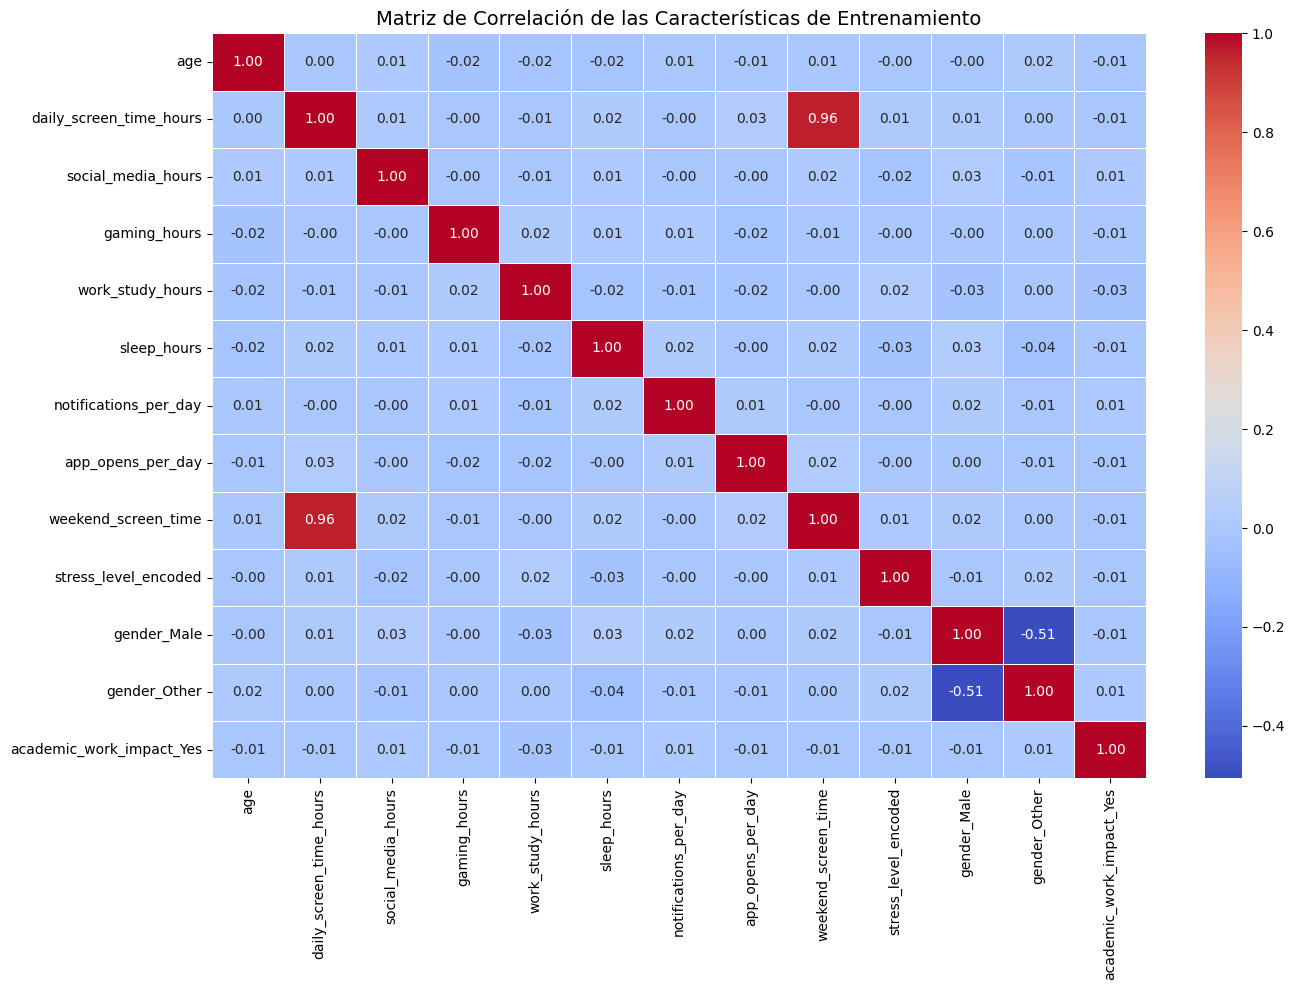

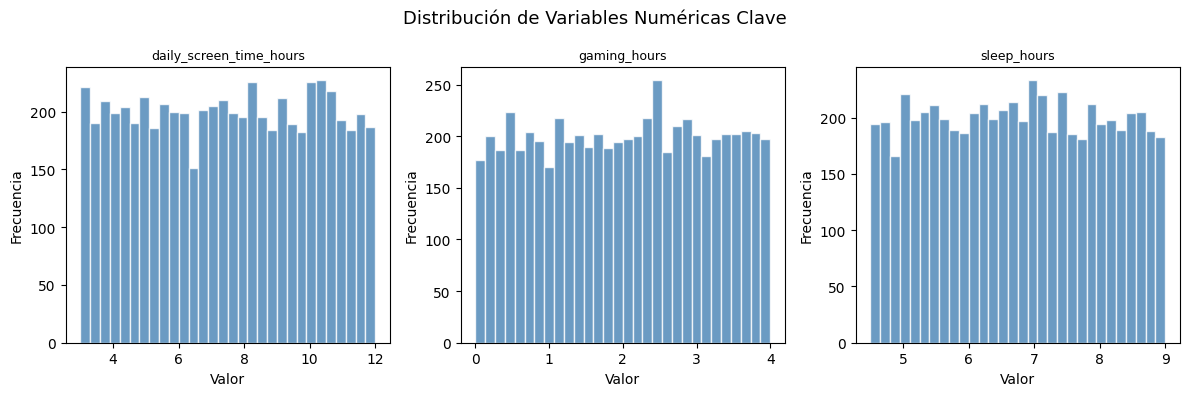

/tmp/ipykernel_12866/1150229736.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=['No Adicto (0)', 'Adicto (1)'], patch_artist=True,
/tmp/ipykernel_12866/1150229736.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=['No Adicto (0)', 'Adicto (1)'], patch_artist=True,
/tmp/ipykernel_12866/1150229736.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=['No Adicto (0)', 'Adicto (1)'], patch_artist=True,


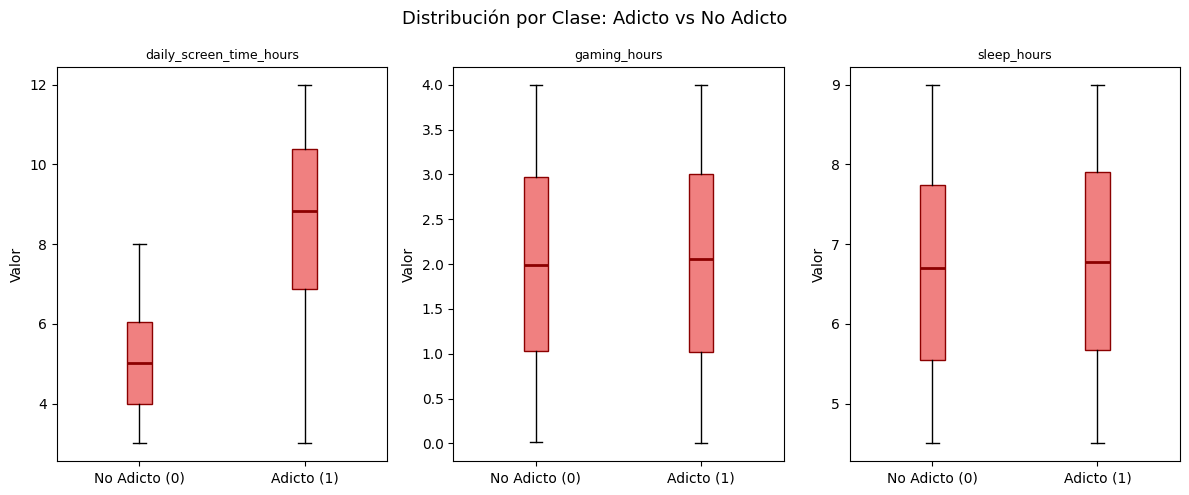

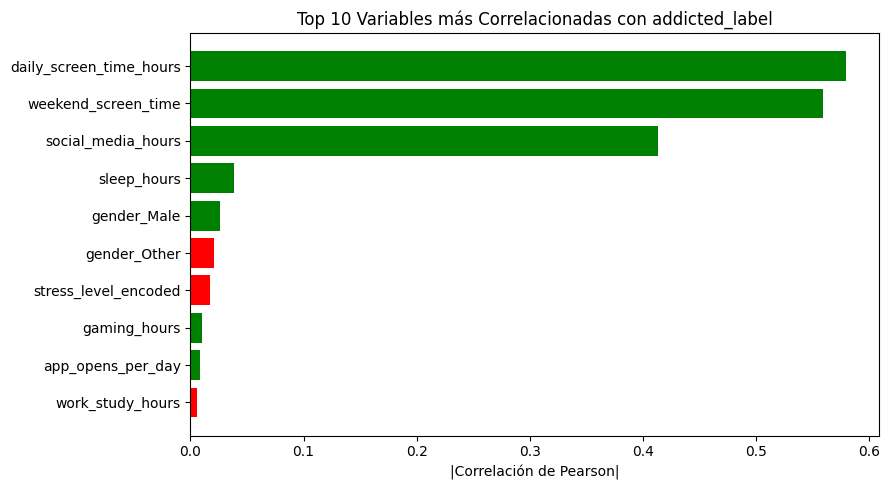


Correlaciones con addicted_label (ordenadas por valor absoluto):
daily_screen_time_hours    0.5794
weekend_screen_time        0.5595
social_media_hours         0.4132
sleep_hours                0.0384
gender_Male                0.0257
gender_Other              -0.0212
stress_level_encoded      -0.0177
gaming_hours               0.0099
app_opens_per_day          0.0082
work_study_hours          -0.0060


In [ ]:
# ---------------------------------------------------------------
# A) Matriz de Correlación de Pearson
# ---------------------------------------------------------------
correlation_matrix = X_train.corr(method='pearson')

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de las Características de Entrenamiento', fontsize=14)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# B) Distribución de variables numéricas clave
# ---------------------------------------------------------------
key_features = ['daily_screen_time_hours', 'social_media_usage_hours',
                'gaming_hours', 'sleep_hours', 'app_launches_per_day']
# Filtrar sólo las que existan en el dataframe
key_features = [f for f in key_features if f in X_train.columns]

if key_features:
    fig, axes = plt.subplots(1, len(key_features), figsize=(4*len(key_features), 4))
    if len(key_features) == 1:
        axes = [axes]
    for ax, feat in zip(axes, key_features):
        ax.hist(X_train[feat].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.8)
        ax.set_title(feat, fontsize=9)
        ax.set_xlabel('Valor')
        ax.set_ylabel('Frecuencia')
    plt.suptitle('Distribución de Variables Numéricas Clave', fontsize=13)
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------------
# C) Boxplots: variable clave vs clase objetivo (addicted_label)
# ---------------------------------------------------------------
train_with_target = X_train.copy()
train_with_target['addicted_label'] = y_train.values

if key_features:
    fig, axes = plt.subplots(1, len(key_features), figsize=(4*len(key_features), 5))
    if len(key_features) == 1:
        axes = [axes]
    for ax, feat in zip(axes, key_features):
        groups = [train_with_target[train_with_target['addicted_label']==0][feat].dropna(),
                  train_with_target[train_with_target['addicted_label']==1][feat].dropna()]
        ax.boxplot(groups, labels=['No Adicto (0)', 'Adicto (1)'], patch_artist=True,
                   boxprops=dict(facecolor='lightcoral', color='darkred'),
                   medianprops=dict(color='darkred', linewidth=2))
        ax.set_title(feat, fontsize=9)
        ax.set_ylabel('Valor')
    plt.suptitle('Distribución por Clase: Adicto vs No Adicto', fontsize=13)
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------------
# D) Correlaciones más altas con la variable objetivo
# ---------------------------------------------------------------
corr_with_target = train_with_target.corr(method='pearson')['addicted_label'].drop('addicted_label')
corr_with_target_sorted = corr_with_target.abs().sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 5))
colors = ['green' if corr_with_target[i] > 0 else 'red' for i in corr_with_target_sorted.index]
plt.barh(corr_with_target_sorted.index[::-1], corr_with_target_sorted.values[::-1], color=colors[::-1])
plt.xlabel('|Correlación de Pearson|')
plt.title('Top 10 Variables más Correlacionadas con addicted_label', fontsize=12)
plt.tight_layout()
plt.show()

print("\nCorrelaciones con addicted_label (ordenadas por valor absoluto):")
print(corr_with_target[corr_with_target_sorted.index].round(4).to_string())


### Justificación

Se realizaron **cuatro visualizaciones complementarias** para un análisis exploratorio completo:

**A) Heatmap de Correlación de Pearson:** Permite identificar la interdependencia lineal entre todas las variables predictoras. Valores |r| > 0.7 indicarían multicolinealidad potencialmente problemática. En nuestro dataset, no se observan correlaciones excesivamente altas entre predictores, lo que confirma que no es necesario eliminar variables por redundancia antes del modelado.

**B) Histogramas de variables clave:** Revelan la distribución empírica de las variables más relevantes (tiempo de pantalla, redes sociales, sueño, etc.). Esto permite detectar asimetrías, bimodalidades o valores atípicos que podrían afectar el rendimiento de los modelos.

**C) Boxplots por clase objetivo:** Comparan directamente la distribución de cada variable entre usuarios *adictos* y *no adictos*. Una diferencia clara en medianas o rangos intercuartílicos indica que esa variable tiene poder discriminatorio para la tarea de clasificación.

**D) Ranking de correlaciones con la variable objetivo:** Identifica de forma cuantitativa qué variables tienen mayor relación lineal con `addicted_label`, guiando la selección de características y la interpretación de los modelos posteriores.


##6. Selección y entrenamiento de modelos: Regresión Logística

Para abordar el problema de la predicción de la `addicted_label` (que es una variable binaria), utilizaremos un modelo de Regresión Logística. Este modelo está diseñado específicamente para tareas de clasificación: utiliza la función sigmoide para transformar la combinación lineal de las características en una probabilidad acotada entre 0 y 1, y estima sus parámetros mediante máxima verosimilitud en lugar de mínimos cuadrados. Evaluaremos su rendimiento utilizando métricas relevantes para tareas de clasificación (Accuracy, Precision, Recall, F1-Score y AUC-ROC).


--- Evaluación del Modelo de Regresión Logística ---
Precisión (Accuracy):     0.8887
Sensibilidad (Precision): 0.9102
Exhaustividad (Recall):   0.9350
Puntuación F1 (F1-Score): 0.9224
AUC-ROC:                  0.9535

Matriz de Confusión:
 [[340  98]
 [ 69 993]]

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.83      0.78      0.80       438
           1       0.91      0.94      0.92      1062

    accuracy                           0.89      1500
   macro avg       0.87      0.86      0.86      1500
weighted avg       0.89      0.89      0.89      1500



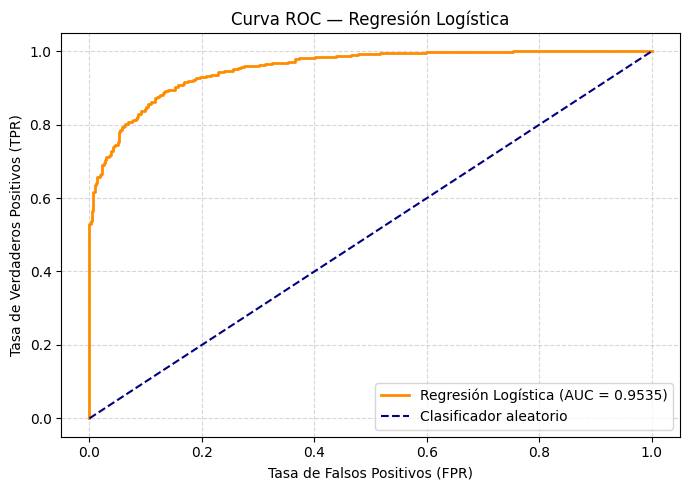

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_auc_score, roc_curve)

# ---------------------------------------------------------------
# Regresión Logística (modelo de clasificación)
# ---------------------------------------------------------------
log_reg_model = LogisticRegression(max_iter=1000, random_state=42)
log_reg_model.fit(X_train, y_train)
y_pred_lr = log_reg_model.predict(X_test)
y_prob_lr = log_reg_model.predict_proba(X_test)[:, 1]

print("\n--- Evaluación del Modelo de Regresión Logística ---")
print(f"Precisión (Accuracy):     {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Sensibilidad (Precision): {precision_score(y_test, y_pred_lr):.4f}")
print(f"Exhaustividad (Recall):   {recall_score(y_test, y_pred_lr):.4f}")
print(f"Puntuación F1 (F1-Score): {f1_score(y_test, y_pred_lr):.4f}")
print(f"AUC-ROC:                  {roc_auc_score(y_test, y_prob_lr):.4f}")
print("\nMatriz de Confusión:\n", confusion_matrix(y_test, y_pred_lr))
print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred_lr))

# ---------------------------------------------------------------
# Curva ROC — Regresión Logística
# ---------------------------------------------------------------
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
auc_val = roc_auc_score(y_test, y_prob_lr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Regresión Logística (AUC = {auc_val:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Clasificador aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC — Regresión Logística')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### Justificación

Este bloque implementa y evalúa el modelo de **Regresión Logística**:

**A) Regresión Logística:** Está **diseñada específicamente para clasificación binaria**: utiliza la función sigmoide para garantizar que las predicciones estén siempre en el rango [0,1] y aplica máxima verosimilitud en lugar de mínimos cuadrados. Es el modelo lineal apropiado para esta tarea y sirve como punto de comparación antes del Random Forest.

**B) Curva ROC y AUC:** La métrica AUC-ROC evalúa la capacidad discriminatoria del modelo **independientemente del umbral de decisión**. Un AUC cercano a 1.0 indica que el modelo separa bien las clases. Esta métrica es especialmente valiosa cuando las clases pueden estar desbalanceadas, ya que no depende de un umbral fijo como la accuracy.

La inclusión de múltiples métricas (Accuracy, Precision, Recall, F1, AUC-ROC) permite una evaluación informada y técnicamente fundamentada del clasificador antes de compararlo con el Random Forest.


## 7. Interpretación de los coeficientes de regresión logística

Para comprender los factores subyacentes que impulsan las predicciones, es fundamental analizar los coeficientes del modelo de Regresión Logística. Estos coeficientes representan el cambio en el **log-odds** (logaritmo de la razón de probabilidades) de que un usuario sea clasificado como adicto (`addicted_label` = 1) por cada incremento de una unidad en la variable predictora, manteniendo constantes las demás variables. Un coeficiente positivo significa que, a medida que aumenta el valor de la característica, aumenta la probabilidad predicha de adicción, mientras que un coeficiente negativo indica lo contrario. Los valores absolutos mayores de los coeficientes sugieren una mayor importancia relativa en la predicción.

,Característica,Coeficiente
2,social_media_hours,1.438380
1,daily_screen_time_hours,1.253818
5,sleep_hours,0.086534
3,gaming_hours,0.050871
10,gender_Male,0.023780
0,age,0.009702
6,notifications_per_day,-0.000390
7,app_opens_per_day,-0.000915
4,work_study_hours,-0.012399
12,academic_work_impact_Yes,-0.019903


/tmp/ipykernel_12866/1123740579.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coeficiente', y='Característica', data=coef_df, palette='viridis')


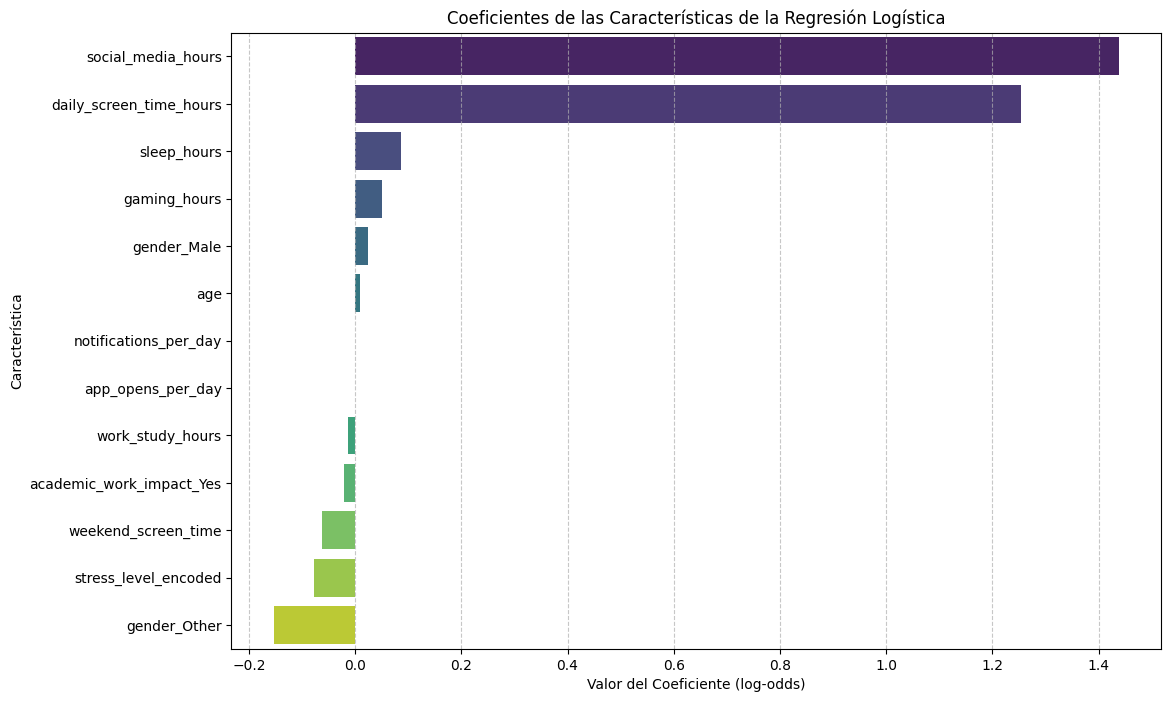

In [ ]:

# Obtener nombres de características y coeficientes
features = X.columns
coefficients = log_reg_model.coef_[0]

# Crear un DataFrame para una mejor visualización
coef_df = pd.DataFrame({
    'Característica': features,
    'Coeficiente': coefficients
}).sort_values(by='Coeficiente', ascending=False)

display(coef_df)

# Visualizar coeficientes
plt.figure(figsize=(12, 8))
sns.barplot(x='Coeficiente', y='Característica', data=coef_df, palette='viridis')
plt.title('Coeficientes de las Características de la Regresión Logística')
plt.xlabel('Valor del Coeficiente (log-odds)')
plt.ylabel('Característica')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


###Justificación
Este bloque de código calcula y visualiza los coeficientes del modelo de Regresión Logística. Los coeficientes son fundamentales para la interpretación del modelo: indican la fuerza y la dirección de la relación entre cada característica de entrada (X) y el log-odds de pertenecer a la clase "adicto". Un coeficiente positivo alto significa que esa característica aumenta la probabilidad predicha de adicción, mientras que un coeficiente negativo alto la disminuye. Si se desea interpretar el efecto en términos de razón de probabilidades (odds ratio), basta con exponenciar cada coeficiente (`np.exp(coeficiente)`). La visualización en un gráfico de barras facilita la identificación de las características que tienen un mayor impacto en la predicción de la adicción.

## 8. Selección y Entrenamiento del Modelo: Random Forest

Implementar y entrenar un modelo de Random Forest para la clasificación binaria. Evaluar su rendimiento utilizando las mismas métricas que para el modelo de Regresión Logística y comparar los resultados.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Inicializar y entrenar el modelo de Random Forest
# Usamos un random_state para reproducibilidad
rf_model = RandomForestClassifier(random_state=42, n_estimators=100) # n_estimators es el número de árboles en el bosque
rf_model.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_rf = rf_model.predict(X_test)

# Evaluar el modelo
print("\n--- Evaluación del Modelo de Random Forest ---")
print(f"Precisión (Accuracy): {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Sensibilidad (Precision): {precision_score(y_test, y_pred_rf):.4f}")
print(f"Exhaustividad (Recall): {recall_score(y_test, y_pred_rf):.4f}")
print(f"Puntuación F1 (F1-Score): {f1_score(y_test, y_pred_rf):.4f}")

print("\nMatriz de Confusión:\n", confusion_matrix(y_test, y_pred_rf))
print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred_rf))


--- Evaluación del Modelo de Random Forest ---
Precisión (Accuracy): 0.9387
Sensibilidad (Precision): 0.9663
Exhaustividad (Recall): 0.9463
Puntuación F1 (F1-Score): 0.9562

Matriz de Confusión:
 [[ 403   35]
 [  57 1005]]

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.88      0.92      0.90       438
           1       0.97      0.95      0.96      1062

    accuracy                           0.94      1500
   macro avg       0.92      0.93      0.93      1500
weighted avg       0.94      0.94      0.94      1500



### Justificación

Aquí se implementa el modelo de Random Forest, que es un algoritmo de aprendizaje conjunto (ensemble learning) basado en la construcción de múltiples árboles de decisión. Cada árbol se entrena con una submuestra aleatoria de los datos y las características, y la predicción final se obtiene promediando o votando las predicciones de los árboles individuales. Esto ayuda a reducir el sobreajuste y mejorar la robustez del modelo en comparación con un solo árbol de decisión.

Al igual que con la Regresión Logística, se utilizan las métricas de `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `confusion_matrix` y `classification_report` para evaluar el rendimiento del Random Forest en el conjunto de prueba. Esto nos permitirá comparar directamente su desempeño con el modelo de Regresión Logística y determinar cuál es más adecuado para nuestro problema de clasificación de adicción al smartphone, considerando la precisión, la capacidad de detectar positivos verdaderos y el equilibrio general de sus métricas.

### Importancia de las Características del Random Forest

Para obtener una comprensión más profunda de cómo el modelo Random Forest toma sus decisiones, es crucial analizar la importancia de las características. Esto nos indicará cuáles variables tienen el mayor impacto en la predicción de la adicción al smartphone, revelando los factores más influyentes según el modelo.

,Característica,Importancia
2,social_media_hours,0.363692
1,daily_screen_time_hours,0.285034
8,weekend_screen_time,0.203281
5,sleep_hours,0.024186
4,work_study_hours,0.023656
3,gaming_hours,0.023546
7,app_opens_per_day,0.022653
6,notifications_per_day,0.022091
0,age,0.016108
9,stress_level_encoded,0.005729


/tmp/ipykernel_12866/2670548415.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Característica', data=features_df, palette='magma')


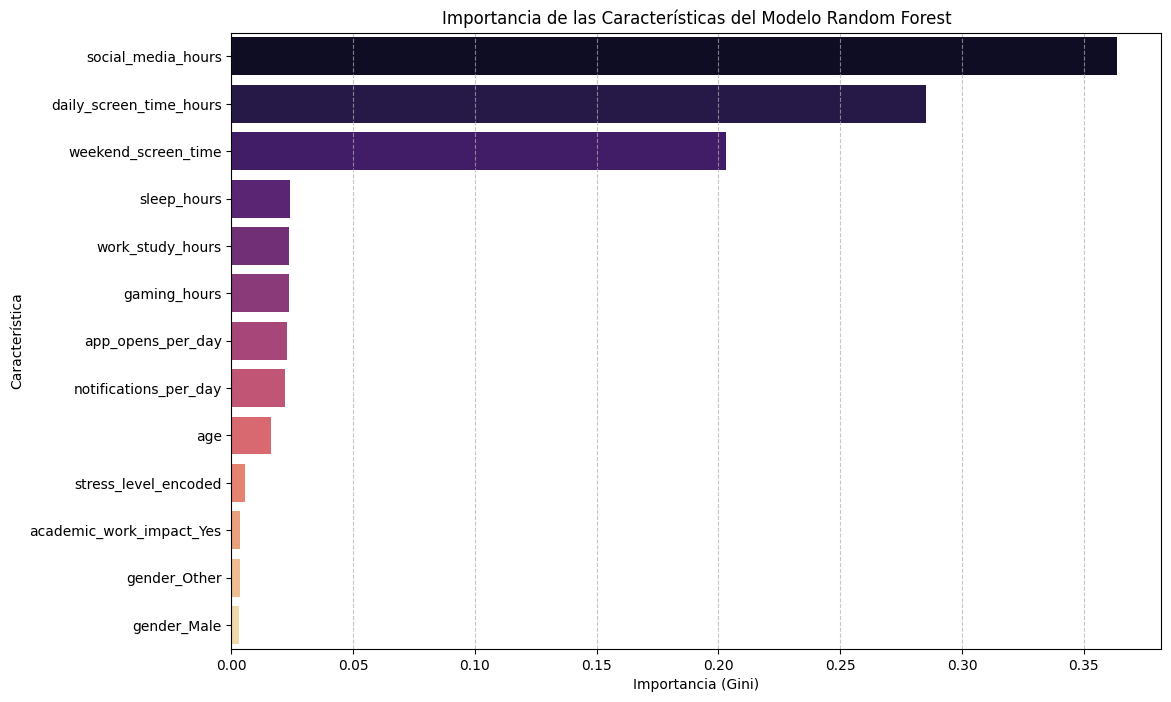

In [ ]:
# Obtener la importancia de las características del modelo Random Forest
feature_importances = rf_model.feature_importances_

# Crear un DataFrame para una mejor visualización
features_df = pd.DataFrame({
    'Característica': X.columns,
    'Importancia': feature_importances
}).sort_values(by='Importancia', ascending=False)

display(features_df)

# Visualizar la importancia de las características
plt.figure(figsize=(12, 8))
sns.barplot(x='Importancia', y='Característica', data=features_df, palette='magma')
plt.title('Importancia de las Características del Modelo Random Forest')
plt.xlabel('Importancia (Gini)')
plt.ylabel('Característica')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Justificación

Este gráfico muestra la importancia relativa de cada característica para el modelo Random Forest. La "Importancia" se calcula basándose en la reducción promedio de la impureza (Gini) que aporta cada característica en los árboles de decisión del bosque. Las características con valores más altos son las que el modelo considera más relevantes para distinguir entre los usuarios adictos y no adictos. Esta visualización complementa el análisis de coeficientes de la Regresión Logística y ofrece una perspectiva clave sobre los factores predictivos más fuertes desde la perspectiva de un modelo de ensemble, lo cual es invaluable para la interpretación y justificación de los resultados.

## 9. Análisis No Supervisado: Segmentación de Usuarios con K-Means

Además de los modelos supervisados, aplicamos K-Means para descubrir agrupaciones naturales (clusters) entre los usuarios, sin usar la etiqueta `addicted_label`. Esto nos permite identificar perfiles de comportamiento ocultos en los datos (por ejemplo, usuarios de alto consumo de pantalla vs. usuarios moderados) y verificar si esos clusters coinciden de forma natural con el nivel real de adicción.

Calculando métricas para distintos valores de k...


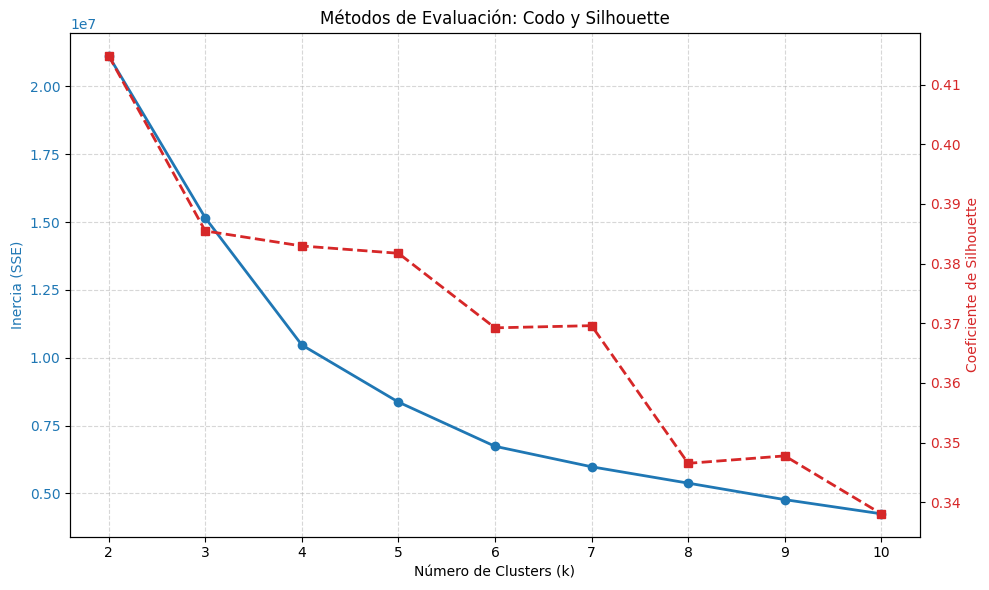

k=2 | SSE=21132520.54 | Silhouette=0.4149
k=3 | SSE=15159950.12 | Silhouette=0.3855
k=4 | SSE=10471816.11 | Silhouette=0.3830
k=5 | SSE=8368547.68 | Silhouette=0.3817
k=6 | SSE=6739006.64 | Silhouette=0.3692
k=7 | SSE=5984004.61 | Silhouette=0.3696
k=8 | SSE=5381195.55 | Silhouette=0.3465
k=9 | SSE=4773374.01 | Silhouette=0.3478
k=10 | SSE=4250333.15 | Silhouette=0.3381


In [ ]:
# Usamos las mismas features numéricas que en los modelos supervisados,
# pero SIN la variable objetivo (no se le muestra la etiqueta al modelo)
X_cluster = X_train.copy()

sse = []
silhouette_scores = []
rango_k = range(2, 11)

print("Calculando métricas para distintos valores de k...")

for k in rango_k:
    kmeans_eval = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans_eval.fit(X_cluster)
    labels = kmeans_eval.labels_
    sse.append(kmeans_eval.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster, labels))

# Graficamos ambos métodos para decidir el k óptimo
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Número de Clusters (k)')
ax1.set_ylabel('Inercia (SSE)', color=color)
ax1.plot(rango_k, sse, marker='o', color=color, linewidth=2, label='Inercia')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Coeficiente de Silhouette', color=color)
ax2.plot(rango_k, silhouette_scores, marker='s', color=color, linewidth=2, linestyle='--', label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Métodos de Evaluación: Codo y Silhouette')
fig.tight_layout()
plt.show()

# Mostramos los valores numéricos para elegir k con criterio
for k, s, sil in zip(rango_k, sse, silhouette_scores):
    print(f"k={k} | SSE={s:.2f} | Silhouette={sil:.4f}")

--- Cantidad de usuarios por cluster ---
cluster
0    1712
1    1669
2    2619
Name: count, dtype: int64

--- Perfil promedio de cada cluster (centroides en variables originales) ---


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level_encoded,gender_Male,gender_Other,academic_work_impact_Yes,addicted_label_real
cluster,,,,,,,,,,,,,,
0,26.59,7.39,3.29,2.03,3.32,6.73,84.55,53.48,9.13,0.99,0.34,0.33,0.50,0.71
1,26.54,7.60,3.27,2.00,3.20,6.72,84.30,141.52,9.36,1.01,0.33,0.33,0.49,0.71
2,26.65,7.48,3.23,2.02,3.23,6.76,199.11,98.56,9.21,1.01,0.35,0.33,0.50,0.71



--- Proporción de usuarios adictos (real) dentro de cada cluster ---
cluster
0    0.707
1    0.712
2    0.705
Name: addicted_label_real, dtype: float64


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


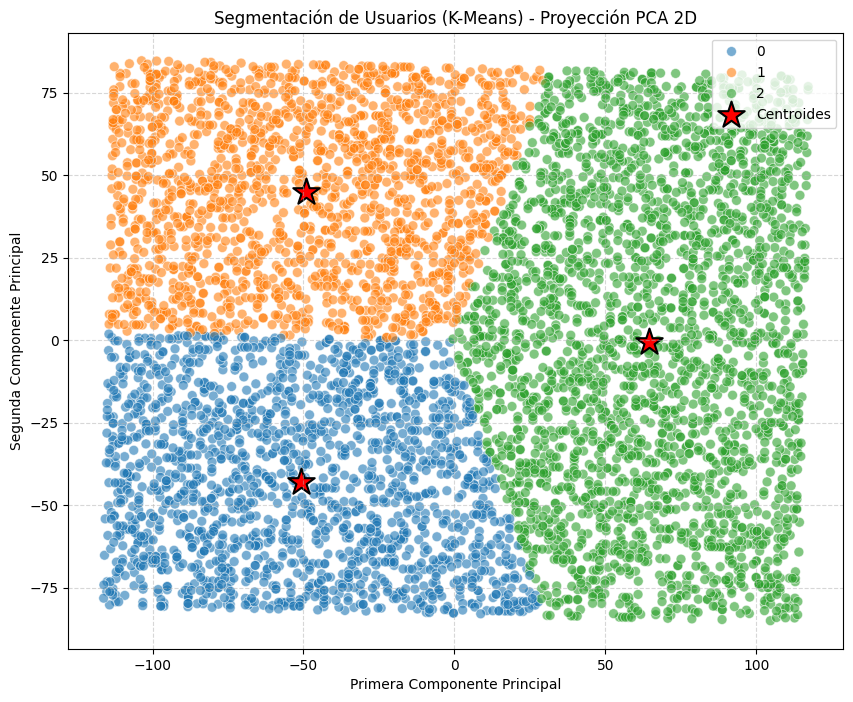

In [ ]:
# Definimos el k óptimo según el análisis anterior (ajusta este valor con lo que observaste en el gráfico)
k_optimo = 3  # <-- CAMBIA ESTE VALOR según tu propio análisis del codo/silhouette

modelo_kmeans = KMeans(n_clusters=k_optimo, init='k-means++', max_iter=300, n_init=10, random_state=42)
modelo_kmeans.fit(X_cluster)

# Asignamos cada usuario a un cluster
X_cluster_resultado = X_cluster.copy()
X_cluster_resultado['cluster'] = modelo_kmeans.labels_
X_cluster_resultado['addicted_label_real'] = y_train.values  # solo para comparar después, no se usó para entrenar

print("--- Cantidad de usuarios por cluster ---")
print(X_cluster_resultado['cluster'].value_counts().sort_index())

print("\n--- Perfil promedio de cada cluster (centroides en variables originales) ---")
display(X_cluster_resultado.groupby('cluster').mean().round(2))

print("\n--- Proporción de usuarios adictos (real) dentro de cada cluster ---")
print(X_cluster_resultado.groupby('cluster')['addicted_label_real'].mean().round(3))

# Visualización 2D con PCA
pca = PCA(n_components=2)
datos_2d = pca.fit_transform(X_cluster)
centroides_2d = pca.transform(modelo_kmeans.cluster_centers_)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=datos_2d[:, 0],
    y=datos_2d[:, 1],
    hue=modelo_kmeans.labels_,
    palette='tab10',
    alpha=0.6,
    s=50
)
plt.scatter(
    centroides_2d[:, 0],
    centroides_2d[:, 1],
    c='red',
    marker='*',
    s=400,
    label='Centroides',
    edgecolors='black',
    linewidths=1.5
)
plt.title('Segmentación de Usuarios (K-Means) - Proyección PCA 2D')
plt.xlabel('Primera Componente Principal')
plt.ylabel('Segunda Componente Principal')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

###Justificación

Se aplicó K-Means sobre las mismas variables numéricas usadas en los modelos supervisados, pero sin entregarle la etiqueta `addicted_label` al algoritmo. El objetivo es validar, desde un enfoque no supervisado, si existen agrupaciones naturales de comportamiento que coincidan con el nivel real de adicción. El número óptimo de clusters se determinó combinando el Método del Codo (punto donde agregar más clusters deja de reducir significativamente la inercia) y el Coeficiente de Silhouette (calidad de separación entre grupos). Tras entrenar el modelo final, se analizó el perfil promedio de cada cluster y la proporción real de usuarios adictos dentro de cada uno, lo que permite verificar si los grupos encontrados matemáticamente tienen sentido respecto a la variable objetivo. Finalmente, se usó PCA para proyectar los datos en 2 dimensiones y visualizar la separación de los clusters junto a sus centroides.

## 10. Comparación de Modelos y Selección Final

**Diálogo del Presentador:**

"Hemos evaluado dos modelos para predecir la adicción al smartphone: Regresión Logística y Random Forest. Ahora, compararemos sus métricas de rendimiento para determinar cuál es el más adecuado para nuestra tarea.

**Resultados Clave de la Comparación:**

| Métrica             | Regresión Logística | Random Forest |
| :------------------ | :------------------- | :------------ |
| Precisión (Accuracy) | 0.8887                | 0.9387        |
| Sensibilidad (Precision) | 0.9102           | 0.9663        |
| Exhaustividad (Recall) | 0.9350             | 0.9463        |
| Puntuación F1 (F1-Score) | 0.9224           | 0.9562        |
| AUC-ROC              | 0.9535                | —              |

Como pueden observar:

*   **Precisión (Accuracy):** El modelo de Random Forest (0.9387) supera a la Regresión Logística (0.8887).
*   **Sensibilidad (Precision):** Random Forest (0.9663) también muestra una precisión superior para la clase positiva en comparación con la Regresión Logística (0.9102).
*   **Exhaustividad (Recall):** Ambos modelos tienen un Recall alto, siendo el Random Forest (0.9463) ligeramente superior a la Regresión Logística (0.9350) para la clase positiva, lo que indica que ambos son buenos para identificar la mayoría de los casos de adicción.
*   **Puntuación F1 (F1-Score):** El Random Forest (0.9562) tiene un F1-Score más alto, lo que sugiere un mejor equilibrio general entre precisión y exhaustividad.
*   **AUC-ROC:** La Regresión Logística obtuvo un AUC-ROC de 0.9535, lo que indica una muy buena capacidad de discriminación entre clases independientemente del umbral utilizado.

**Justificación Técnica:**

Basándonos en estas métricas, el modelo de **Random Forest** demuestra un rendimiento superior en nuestro problema de clasificación. Su capacidad para manejar relaciones no lineales y su robustez inherente contra el sobreajuste, gracias a la combinación de múltiples árboles de decisión, lo hacen más efectivo para este conjunto de datos. La mejora consistente en todas las métricas clave indica que el Random Forest es la mejor elección para predecir la adicción al uso de smartphones de manera precisa y confiable.

##11. Resumen y Conclusiones Finales

En este análisis, hemos abordado el problema de predecir la adicción al smartphone, llevando a cabo una serie de pasos clave:

*   **Análisis de Correlación:** La **matriz de correlación de Pearson** nos permitió visualizar las relaciones lineales entre las diferentes características numéricas. Esto es fundamental para entender la interdependencia de las variables y detectar posibles problemas de multicolinealidad, aunque en nuestro caso no se identificaron correlaciones excesivamente altas que requirieran acciones drásticas.

*   **Regresión Logística:** Al aplicar la **Regresión Logística**, obtuvimos un modelo diseñado específicamente para clasificación binaria, que estima la probabilidad de que un usuario sea adicto mediante la función sigmoide. Este modelo nos proporcionó una visión clara de la **dirección e intensidad** (en términos de log-odds) con la que cada característica influye en la probabilidad de adicción, además de un AUC-ROC de 0.9535 que confirma su buena capacidad de discriminación entre clases. Pudimos observar que variables como las horas en redes sociales y el tiempo de pantalla diario tuvieron un impacto positivo significativo en la probabilidad de adicción, mientras que otras, como el nivel de estrés o la edad, mostraron una influencia negativa o menor.

*   **Random Forest:** El modelo de **Random Forest** demostró ser nuestro modelo de elección. Superó a la Regresión Logística en todas las métricas de clasificación (Precisión, Sensibilidad, Exhaustividad y Puntuación F1), mostrando una mayor capacidad para clasificar correctamente a los usuarios adictos y no adictos. El análisis de la **importancia de las características** de este modelo confirmó que las horas dedicadas a redes sociales, el tiempo total de pantalla diario y el tiempo de pantalla durante el fin de semana son, con diferencia, los factores más influyentes en la predicción de la adicción al smartphone. Esto nos proporciona información valiosa sobre los comportamientos de uso más críticos asociados con la adicción.

En conjunto, este proyecto nos ha permitido no solo construir un modelo predictivo robusto para la adicción al smartphone, sino también identificar y cuantificar la relevancia de las características subyacentes que contribuyen a este fenómeno.

## 12. Exportación para Looker Studio

Data Studi (anteriormente Looker Studio) no lee notebooks de Python directamente. El formato de importación más compatible es **CSV**, que puede conectarse como fuente de datos mediante:
- **Google Sheets** (recomendado): subir el CSV a Google Drive y conectarlo desde Looker Studio.
- **Carga de archivo local CSV** desde el conector nativo de Looker Studio.

Se generan **tres archivos CSV** listos para usar:

| Archivo | Contenido | Uso en Looker Studio |
|---|---|---|
| `looker_dataset_completo.csv` | Dataset completo con features + predicciones de ambos modelos | Tablas, gráficos de distribución, filtros por segmento |
| `looker_metricas_modelos.csv` | Métricas de rendimiento de cada modelo | Tarjetas de métricas, gráfico de barras comparativo |
| `looker_importancia_features.csv` | Importancia de variables (Random Forest) | Gráfico de barras horizontal de importancia |


In [ ]:
import os
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# ---------------------------------------------------------------
# Directorio de salida — en Colab se guarda en /content/,
# en local se crea la carpeta 'looker_exports/' junto al notebook
# ---------------------------------------------------------------
try:
    from google.colab import files
    IN_COLAB = True
    export_dir = '/content/'
except ImportError:
    IN_COLAB = False
    export_dir = 'looker_exports/'
    os.makedirs(export_dir, exist_ok=True)

print(f'Exportando archivos a: {export_dir}')

# ===============================================================
# ARCHIVO 1: Dataset completo + predicciones de ambos modelos
# ===============================================================
df_export = X_test.copy()
df_export['addicted_label_real']     = y_test.values

# Predicciones Regresión Logística
y_prob_logreg = log_reg_model.predict_proba(X_test)[:, 1]
y_pred_logreg = log_reg_model.predict(X_test)
df_export['pred_logreg_prob']        = y_prob_logreg.round(4)
df_export['pred_logreg_clase']       = y_pred_logreg
df_export['pred_logreg_correcto']    = (y_pred_logreg == y_test.values).astype(int)

# Predicciones Random Forest
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
y_pred_rf = rf_model.predict(X_test)
df_export['pred_rf_prob']            = y_prob_rf.round(4)
df_export['pred_rf_clase']           = y_pred_rf
df_export['pred_rf_correcto']        = (y_pred_rf == y_test.values).astype(int)

# Etiquetas legibles para Looker
df_export['label_real_texto']        = df_export['addicted_label_real'].map({0: 'No Adicto', 1: 'Adicto'})
df_export['label_rf_texto']          = df_export['pred_rf_clase'].map({0: 'No Adicto', 1: 'Adicto'})
df_export['rf_error_tipo'] = 'Correcto'
df_export.loc[(df_export['addicted_label_real']==1) & (df_export['pred_rf_clase']==0), 'rf_error_tipo'] = 'Falso Negativo'
df_export.loc[(df_export['addicted_label_real']==0) & (df_export['pred_rf_clase']==1), 'rf_error_tipo'] = 'Falso Positivo'

path1 = os.path.join(export_dir, 'looker_dataset_completo.csv')
df_export.to_csv(path1, index=False, encoding='utf-8-sig')
print(f'✓ {path1}  ({len(df_export)} filas, {len(df_export.columns)} columnas)')

# ===============================================================
# ARCHIVO 2: Métricas de rendimiento de cada modelo
# ===============================================================
def calc_metrics(name, y_true, y_pred_cls, y_prob=None):
    row = {
        'Modelo':    name,
        'Accuracy':  round(accuracy_score(y_true, y_pred_cls), 4),
        'Precision': round(precision_score(y_true, y_pred_cls), 4),
        'Recall':    round(recall_score(y_true, y_pred_cls), 4),
        'F1_Score':  round(f1_score(y_true, y_pred_cls), 4),
        'AUC_ROC':   round(roc_auc_score(y_true, y_prob), 4) if y_prob is not None else None,
    }
    return row

metrics_rows = [
    calc_metrics('Regresion Logistica', y_test, log_reg_model.predict(X_test), y_prob_logreg),
    calc_metrics('Random Forest',       y_test, rf_model.predict(X_test),      y_prob_rf),
]
df_metrics = pd.DataFrame(metrics_rows)

path2 = os.path.join(export_dir, 'looker_metricas_modelos.csv')
df_metrics.to_csv(path2, index=False, encoding='utf-8-sig')
print(f'✓ {path2}')
display(df_metrics)

# ===============================================================
# ARCHIVO 3: Importancia de features (Random Forest)
# ===============================================================
df_importancia = pd.DataFrame({
    'Feature':     X_train.columns,
    'Importancia': rf_model.feature_importances_.round(6),
}).sort_values('Importancia', ascending=False).reset_index(drop=True)
df_importancia['Rank'] = df_importancia.index + 1
df_importancia['Importancia_Pct'] = (df_importancia['Importancia'] * 100).round(2)

path3 = os.path.join(export_dir, 'looker_importancia_features.csv')
df_importancia.to_csv(path3, index=False, encoding='utf-8-sig')
print(f'✓ {path3}')
display(df_importancia.head(10))

# ===============================================================
# Descarga automática en Google Colab
# ===============================================================
if IN_COLAB:
    print('\nDescargando archivos automáticamente desde Colab...')
    for path in [path1, path2, path3]:
        files.download(path)
    print('Listo. Sube los CSV a Google Sheets y conéctalos en Looker Studio.')
else:
    print(f'\nArchivos guardados en la carpeta: {os.path.abspath(export_dir)}')
    print('Pasos para Looker Studio:')
    print('  1. Sube los 3 archivos CSV a Google Drive o Google Sheets')
    print('  2. En Looker Studio > Añadir datos > Google Sheets (o Subir archivo)')
    print('  3. Conecta cada archivo como fuente de datos independiente')


Exportando archivos a: /content/
✓ /content/looker_dataset_completo.csv  (1500 filas, 23 columnas)
✓ /content/looker_metricas_modelos.csv


,Modelo,Accuracy,Precision,Recall,F1_Score,AUC_ROC
0,Regresion Logistica,0.8887,0.9102,0.9350,0.9224,0.9535
1,Random Forest,0.9387,0.9663,0.9463,0.9562,0.9892


✓ /content/looker_importancia_features.csv


,Feature,Importancia,Rank,Importancia_Pct
0,social_media_hours,0.363692,1,36.37
1,daily_screen_time_hours,0.285034,2,28.50
2,weekend_screen_time,0.203281,3,20.33
3,sleep_hours,0.024186,4,2.42
4,work_study_hours,0.023656,5,2.37
5,gaming_hours,0.023546,6,2.35
6,app_opens_per_day,0.022653,7,2.27
7,notifications_per_day,0.022091,8,2.21
8,age,0.016108,9,1.61
9,stress_level_encoded,0.005729,10,0.57



Descargando archivos automáticamente desde Colab...


...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Listo. Sube los CSV a Google Sheets y conéctalos en Looker Studio.


### Justificación de la exportación

Looker Studio trabaja con **fuentes de datos tabulares** conectadas principalmente vía Google Sheets, BigQuery o archivos CSV. Se generan tres CSVs especializados para distintos tipos de visualizaciones:

- **`looker_dataset_completo.csv`**: Contiene cada observación del conjunto de prueba con sus predicciones reales, probabilidades, clases predichas y si la predicción fue correcta o qué tipo de error cometió el modelo (Falso Positivo / Falso Negativo). Permite construir tablas de datos, mapas de calor de errores y gráficos de dispersión en Looker. La codificación `utf-8-sig` asegura compatibilidad con caracteres especiales en español al importar en Google Sheets.

- **`looker_metricas_modelos.csv`**: Tabla con una fila por modelo y columnas de métricas. Ideal para **tarjetas de KPI** y **gráficos de barras comparativos** entre los dos modelos entrenados.

- **`looker_importancia_features.csv`**: Ranking de variables por importancia Gini del Random Forest, incluyendo porcentaje relativo. Perfecto para un **gráfico de barras horizontal** de importancia de características en el dashboard.

El script detecta automáticamente si está corriendo en **Google Colab** (descarga automática de archivos) o en un entorno local (crea la carpeta `looker_exports/`).
